In [1]:
import os
import argparse
import random
import logging
import torch

from tqdm import tqdm

import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path

from utils import __balance_val_split, __split_of_train_sequence, __log_class_statistics, logger
from datasets.czech_slr_dataset import CzechSLRDataset
from siformer.model import SiFormer, SpoTer
from siformer.utils import train_epoch, evaluate, evaluate_top_k, compute_early_exit_stats, calc_total_params, ConfusionMatrix
from siformer.gaussian_noise import GaussianNoise

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

import time
import datetime
from statistics import mean

In [2]:

def get_default_args():
    parser = argparse.ArgumentParser(add_help=False)

    parser.add_argument("--experiment_name", type=str, default="WLASL_spoter",
                        help="Name of the experiment after which the logs and plots will be named")
    parser.add_argument("--num_classes", type=int, default=100, help="Number of classes to be recognized by the model")
    parser.add_argument("--batch_size", type=int, default=24, help="Number of batch size")
    parser.add_argument("--num_worker", type=int, default=0, help="Number of workers")
    parser.add_argument("--num_seq_elements", type=int, default=108, # [21(hand)*2 +12(body) ]*2
                        help="Hidden dimension of the underlying Transformer model")
    parser.add_argument("--seed", type=int, default=379,
                        help="Seed with which to initialize all the random components of the training")

    # Data
    parser.add_argument("--training_set_path", type=str, default="", help="Path to the training dataset CSV file")
    parser.add_argument("--testing_set_path", type=str, default="", help="Path to the testing dataset CSV file")
    parser.add_argument("--experimental_train_split", type=float, default=None,
                        help="Determines how big a portion of the training set should be employed (intended for the "
                             "gradually enlarging training set experiment from the paper)")

    parser.add_argument("--validation_set", type=str, choices=["from-file", "split-from-train", "none"],
                        default="none",
                        help="Type of validation set construction. See README for further rederence")
    parser.add_argument("--validation_set_size", type=float,
                        help="Proportion of the training set to be split as validation set, if 'validation_size' is set"
                             " to 'split-from-train'")
    parser.add_argument("--validation_set_path", type=str, default="", help="Path to the validation dataset CSV file")

    # Training hyperparameters
    parser.add_argument("--epochs", type=int, default=100, help="Number of epochs to train the model for")
    parser.add_argument("--lr", type=float, default=0.0001, help="Learning rate for the model training")
    parser.add_argument("--log_freq", type=int, default=1,
                        help="Log frequency (frequency of printing all the training info)")

    # Checkpointing
    parser.add_argument("--save_checkpoints", type=bool, default=True,
                        help="Determines whether to save weights checkpoints")

    # Scheduler
    parser.add_argument("--scheduler_factor", type=int, default=0.1, help="Factor for the ReduceLROnPlateau scheduler")
    parser.add_argument("--scheduler_patience", type=int, default=5,
                        help="Patience for the ReduceLROnPlateau scheduler")

    # Gaussian noise normalization
    parser.add_argument("--gaussian_mean", type=int, default=0, help="Mean parameter for Gaussian noise layer")
    parser.add_argument("--gaussian_std", type=int, default=0.001,
                        help="Standard deviation parameter for Gaussian noise layer")

    # Visualization
    parser.add_argument("--plot_stats", type=bool, default=True,
                        help="Determines whether continuous statistics should be plotted at the end")
    parser.add_argument("--plot_lr", type=bool, default=True,
                        help="Determines whether the LR should be plotted at the end")

    # Training time
    parser.add_argument("--record_training_time", type=bool, default=False,
                        help="Determines whether continuous statistics of training time should be record")

    # Model settings
    parser.add_argument("--attn_type", type=str, default='prob', help="The attention mechanism used by the model")
    parser.add_argument("--num_enc_layers", type=int, default=3, help="Determines the number of encoder layers")
    parser.add_argument("--num_com_layers", type=int, default=1, help="Determines the number of communicating layers")
    parser.add_argument("--num_dec_layers", type=int, default=2, help="Determines the number of decoder layers")
    parser.add_argument("--FIM", type=bool, default=True, help=" ")
    parser.add_argument("--IA_encoder", type=bool, default=True, help="Determines whether input adaptive encoder will be used")
    parser.add_argument("--IA_decoder", type=bool, default=False, help="Determines whether input adaptive decoder will be used")
    parser.add_argument("--pat_enc", type=int, default=1, help="Determines the patience of encoder for earlier exist")
    parser.add_argument("--pat_dec", type=int, default=1, help="Determines the patience of decoder for earlier exist")

    return parser


In [3]:
def train(args):
    # MARK: TRAINING PREPARATION AND MODULES

    # Initialize all the random seeds
    random.seed(args.seed)
    np.random.seed(args.seed)
    os.environ["PYTHONHASHSEED"] = str(args.seed)
    torch.manual_seed(args.seed)
    torch.cuda.manual_seed(args.seed)
    torch.cuda.manual_seed_all(args.seed)
    torch.backends.cudnn.deterministic = True
    g = torch.Generator()
    g.manual_seed(args.seed)

    # Set the output format to print into the console and save into LOG file
    

    logger("Experiment parameters:")
    logger(f"\t\t\tnum_com_layers={args.num_com_layers}")
    logger(f"\t\t\tnum_enc_layers={args.num_enc_layers} | pat_enc={args.pat_enc}")
    logger(f"\t\t\tnum_dec_layers={args.num_dec_layers} | pat_enc={args.pat_dec}")

    # Set device to CUDA only if applicable
    device = torch.device("cpu")
    if torch.cuda.is_available():
        print("Cuda is available: True")
        device = torch.device("cuda")

    # Construct the model
    if args.FIM:
        slr_model = SiFormer(num_classes=args.num_classes, num_hid=args.num_seq_elements, attn_type=args.attn_type,
                             num_comm_layers=args.num_com_layers,
                              num_enc_layers=args.num_enc_layers, num_dec_layers=args.num_dec_layers, device=device,
                              IA_encoder=args.IA_encoder, IA_decoder=args.IA_decoder,
                              pat_enc=args.pat_enc, pat_dec=args.pat_dec)
    else:
        slr_model = SpoTer(num_classes=args.num_classes, num_hid=args.num_seq_elements,
                           num_enc_layers=args.num_enc_layers, num_dec_layers=args.num_dec_layers)
    slr_model.train(True)
    slr_model.to(device) 

    # Construct the other modules | Khởi tạo hàm mất mát (loss function)
    cel_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(slr_model.parameters(), lr=args.lr, betas=(0.9, 0.999), weight_decay=1e-8) # Đây là bộ tối ưu hóa (optimizer). Nó chịu trách nhiệm cập nhật trọng số của mô hình dựa trên giá trị mất mát để cải thiện hiệu suất.
    # scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[60, 80], gamma=0.1)  # 40, 60, 80  Đây là bộ lập lịch tốc độ học (learning rate scheduler). Nó sẽ tự động giảm tốc độ học tại các epoch nhất định (milestones=[60, 80]) để giúp mô hình hội tụ tốt hơn.
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs, eta_min=0)

    # Ensure that the path for checkpointing and for images both exist
    Path("out-checkpoints/" + args.experiment_name + "/").mkdir(parents=True, exist_ok=True)
    Path("out-img/").mkdir(parents=True, exist_ok=True)

    # MARK: DATA

    # Training set
    transform = transforms.Compose([GaussianNoise(args.gaussian_mean, args.gaussian_std)]) #Áp dụng một phép biến đổi lên dữ liệu huấn luyện, cụ thể là thêm nhiễu Gaussian. Đây là một kỹ thuật tăng cường dữ liệu (data augmentation) để giúp mô hình tổng quát hóa tốt hơn.

    train_set = CzechSLRDataset(args.training_set_path, transform=transform, augmentations=True) #Đây là một lớp tùy chỉnh để đọc dữ liệu từ các tệp được chỉ định trong args.training_set_path, args.validation_set_path, v.v.

    # Validation set
    if args.validation_set == "from-file":
        val_set = CzechSLRDataset(args.validation_set_path)
        val_loader = DataLoader(val_set, batch_size=args.batch_size, shuffle=True, generator=g,
                                num_workers=args.num_worker)
    elif args.validation_set == "split-from-train":
        train_set, val_set = __balance_val_split(train_set, 0.2)

        val_set.transform = None
        val_set.augmentations = False
        val_loader = DataLoader(val_set, batch_size=args.batch_size, shuffle=True, generator=g,
                                num_workers=args.num_worker)
    else:
        val_loader = None

    # Testing set
    if args.testing_set_path:
        
        eval_set = CzechSLRDataset(args.testing_set_path)
        eval_loader = DataLoader(eval_set, batch_size=args.batch_size, shuffle=True, generator=g,
                                 num_workers=args.num_worker)
        
    else:
        eval_loader = None
    
    # Final training set refinements
    if args.experimental_train_split:
        train_set = __split_of_train_sequence(train_set, args.experimental_train_split)

    train_loader = DataLoader(train_set, batch_size=args.batch_size, shuffle=True, generator=g,
                              num_workers=args.num_worker)

    # MARK: TRAINING
    train_acc, val_acc = 0, 0
    losses, train_accs, val_accs = [], [], []
    lr_progress = []
    top_train_acc, top_val_acc = 0, 0
    checkpoint_index = 0

    if args.experimental_train_split:
        logger(
            "Starting " + args.experiment_name + "_" + str(args.experimental_train_split).replace(".", "") + "...")
    else:
        logger("Starting " + args.experiment_name + "...")

    logger("Training using " + args.training_set_path + "...")

    if args.validation_set == "from-file":
        logger("Validation using " + args.validation_set_path + "...\n\n")

    total_train_time = 0
    avg_train_time_sec_list = []
    for epoch in range(args.epochs):
        start_time = time.time()
        train_loss, _, _, train_acc, avg_train_time = train_epoch(slr_model, train_loader, cel_criterion, optimizer,
                                                                  device, scheduler=scheduler)
        end_time = time.time()
        train_time = end_time - start_time

        losses.append(train_loss.item() / len(train_loader))
        train_accs.append(train_acc)

        if args.record_training_time:
            avg_train_time_sec_list.append(avg_train_time)
            total_train_time += train_time

        if val_loader:
            slr_model.train(False)
            _, _, val_acc = evaluate(slr_model, val_loader, device)
            slr_model.train(True)
            val_accs.append(val_acc)

        # Save checkpoints if they are best in the current subset
        if args.save_checkpoints:
            if train_acc > top_train_acc:
                top_train_acc = train_acc
                torch.save(slr_model, "out-checkpoints/" + args.experiment_name + "/checkpoint_t_" + str(
                    checkpoint_index) + ".pth")

            if val_acc > top_val_acc:
                top_val_acc = val_acc
                torch.save(slr_model, "out-checkpoints/" + args.experiment_name + "/checkpoint_v_" + str(
                    checkpoint_index) + ".pth")

                logger(f'Save checkpoint for [{str(epoch + 1)}] as ' + "out-checkpoints/" + args.experiment_name
                      + "/checkpoint_v_" + str(checkpoint_index) + ".pth")

        if epoch % args.log_freq == 0:
            logger(
                "[" + str(epoch + 1) + "] TRAIN  loss: " + str(train_loss.item() / len(train_loader)) + " acc: " + str(
                    train_acc))
            logger(
                f"[{str(epoch + 1)}] AVG TRAIN time per sample (sec): {str(avg_train_time)} "
            )

            if val_loader:
                logger("[" + str(epoch + 1) + "] VALIDATION  acc: " + str(val_acc))

                logger("[" + str(epoch + 1) + "] VALIDATION  Top 5 acc: " + str(top_val_acc))

            logger("")

        # Reset the top accuracies on static subsets
        if epoch % 10 == 0:
            top_train_acc, top_val_acc = 0, 0
            checkpoint_index += 1

        lr_progress.append(optimizer.param_groups[0]["lr"])

    if args.record_training_time:
        logger(f"Total training time taken over {args.epochs} epochs: {str(datetime.timedelta(seconds=total_train_time))}")
        logger(f"Average training time per sample: {str(mean(avg_train_time_sec_list[1:]))}")

    top_result_top1, top_result_name_top1 = 0, ""
    top_result_topk, top_result_name_topk = 0, ""
    test_accs_t=[]
    test_accs_v=[]

    if eval_loader:
        # MARK: TESTING
        logger("\nTesting checkpointed models starting...\n")
        for i in range(11):            
            for checkpoint_id in ["t", "v"]:
                path_to_load = "out-checkpoints/" + args.experiment_name + "/checkpoint_" + checkpoint_id + "_" + str(i) + ".pth"

                if not os.path.exists(path_to_load):                    
                    continue               

                tested_model = torch.load(path_to_load, weights_only=False)
                tested_model.eval()

                # === Top 1 ===
                _, _, eval_acc_top1 = evaluate(tested_model, eval_loader, device)

                if checkpoint_id == "v":
                    test_accs_v.append(eval_acc_top1)
                else:
                    test_accs_t.append(eval_acc_top1)

                if eval_acc_top1 > top_result_top1:
                    top_result_top1 = eval_acc_top1
                    top_result_name_top1 = args.experiment_name + "/checkpoint_" + checkpoint_id + "_" + str(i)

                # === Top K ===
                _, _, eval_acc_topk = evaluate_top_k(tested_model, eval_loader, device)

                if eval_acc_topk > top_result_topk:
                    top_result_topk = eval_acc_topk
                    top_result_name_topk = args.experiment_name + "/checkpoint_" + checkpoint_id + "_" + str(i)

                logger(
                    f"checkpoint_{checkpoint_id}_{i}  ->  "
                    f"Top 1: {eval_acc_top1:<8} | "
                    f"Top 5: {eval_acc_topk:<8}"
                )

        path_to_load = "out-checkpoints/" + top_result_name_top1 + '.pth'
        if os.path.exists(path_to_load):
            model_top=torch.load(path_to_load, weights_only=False)

            logger('\n=== Parameter statistics ===')
            calc_total_params(model_top)

            model_top.to(device)
            model_top.eval()

            logger('\n=== Number of early exits ===')

            if train_loader:
                train_exited, train_total, train_ratio = compute_early_exit_stats(model_top, train_loader, device)
                logger(f"[Train] {train_exited}/{train_total} | {train_ratio:.2%}")
                logger()
            if val_loader:
                val_exited, val_total, val_ratio = compute_early_exit_stats(model_top, val_loader, device)
                logger(f"[Val]   {val_exited}/{val_total} | {val_ratio:.2%}")
                logger()


            if eval_loader:
                test_exited, test_total, test_ratio = compute_early_exit_stats(model_top, eval_loader, device)
                logger(f"[Test]  {test_exited}/{test_total} | {test_ratio:.2%}")
                logger()

        

        logger("\nThe top result was recorded at " + str(
            top_result_top1) + " testing accuracy. The best checkpoint is " + top_result_name_top1 + ".")

    # PLOT 0: Performance (loss, accuracies) chart plotting
    if args.plot_stats:
        fig, ax = plt.subplots()
        ax.plot(range(1, len(losses) + 1), losses, c="#D64436", label="Training loss")
        ax.plot(range(1, len(train_accs) + 1), train_accs, c="#00B09B", label="Training accuracy")

        if val_loader:
            ax.plot(range(1, len(val_accs) + 1), val_accs, c="#E0A938", label="Validation accuracy")
        
        if len(test_accs_t)>0:
            ax.plot(range(1, len(test_accs_t) + 1), test_accs_t, c="#3366FF", label="Test accuracy (t)")
        
        if len(test_accs_v)>0:
            ax.plot(range(1, len(test_accs_v) + 1), test_accs_v, c="#33FF70", label="Test accuracy (v)")

        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

        ax.set(xlabel="Epoch", ylabel="Accuracy / Loss", title="")
        plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=4, fancybox=True, shadow=True,
                   fontsize="xx-small")
        ax.grid()

        fig.savefig("out-img/" + args.experiment_name + "_loss.png")

    # PLOT 1: Learning rate progress
    if args.plot_lr:
        fig1, ax1 = plt.subplots()
        ax1.plot(range(1, len(lr_progress) + 1), lr_progress, label="LR")
        ax1.set(xlabel="Epoch", ylabel="LR", title="")
        ax1.grid()

        fig1.savefig("out-img/" + args.experiment_name + "_lr.png")

    # PLOT 2: Training time
    if args.record_training_time:
        fig1, ax2 = plt.subplots()
        ax2.plot(range(1, len(avg_train_time_sec_list) + 1), avg_train_time_sec_list,
                 label="AVG Training Time per sample")
        ax2.set(xlabel="Epoch", ylabel="Second", title="")
        ax2.grid()

        fig1.savefig("out-img/" + args.experiment_name + "_tt.png")

    logger("Experiment parameters:")
    logger(f"\t\t\tnum_com_layers={args.num_com_layers}")
    logger(f"\t\t\tnum_enc_layers={args.num_enc_layers} | pat_enc={args.pat_enc}")
    logger(f"\t\t\tnum_dec_layers={args.num_dec_layers} | pat_enc={args.pat_dec}")

    logger("\nAny desired statistics have been plotted.\nThe experiment is finished.")

Experiment parameters:
			num_com_layers=1
			num_enc_layers=3 | pat_enc=1
			num_dec_layers=4 | pat_enc=2
Cuda is available: True
Feature isolated transformer
Using custom PBEEncoder: num_layers= 3 | patience= 1
Using custom PBEEncoder: num_layers= 3 | patience= 1
Using custom PBEEncoder: num_layers= 3 | patience= 1
num_comm_layers = 1
Using custom DecoderLayer


d:\HuuTuan\miniconda\envs\siformer\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Using custom PBEEDecoder: num_layers= 4 | patient= 2
Starting WLASL100...
Training using datasets/WLASL100_train_25fps.csv...
Save checkpoint for [1] as out-checkpoints/WLASL100/checkpoint_v_0.pth
[1] TRAIN  loss: 4.659516521703417 acc: 0.012890625
[1] AVG TRAIN time per sample (sec): 0.09221565612008638 
[1] VALIDATION  acc: 0.01875
[1] VALIDATION  Top 5 acc: 0.01875

Save checkpoint for [2] as out-checkpoints/WLASL100/checkpoint_v_1.pth
[2] TRAIN  loss: 4.302521322375146 acc: 0.061328125
[2] AVG TRAIN time per sample (sec): 0.09282291715390215 
[2] VALIDATION  acc: 0.103125
[2] VALIDATION  Top 5 acc: 0.103125

Save checkpoint for [3] as out-checkpoints/WLASL100/checkpoint_v_1.pth
[3] TRAIN  loss: 3.780798510970356 acc: 0.205859375
[3] AVG TRAIN time per sample (sec): 0.08866147014582268 
[3] VALIDATION  acc: 0.290625
[3] VALIDATION  Top 5 acc: 0.290625

Save checkpoint for [4] as out-checkpoints/WLASL100/checkpoint_v_1.pth
[4] TRAIN  loss: 3.3879753897123246 acc: 0.328515625
[4] AVG 

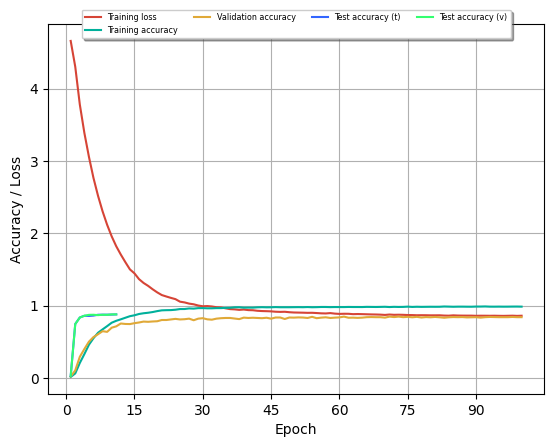

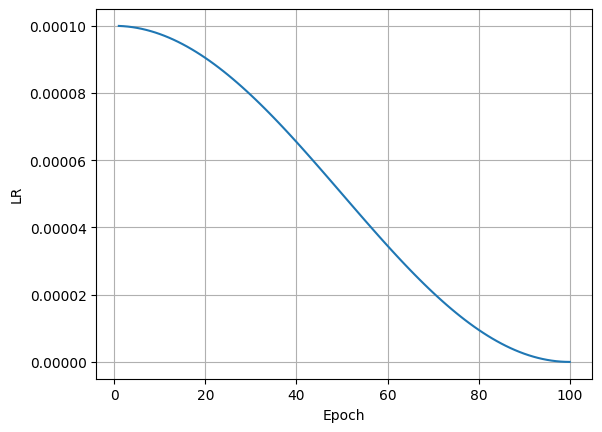

In [4]:
parser = argparse.ArgumentParser("", parents=[get_default_args()], add_help=False)

parser.set_defaults(
        experiment_name="WLASL100",
        training_set_path="datasets/WLASL100_train_25fps.csv",
        testing_set_path="datasets/WLASL100_val_25fps.csv",
        validation_set="split-from-train",
        num_classes=100,
        IA_decoder=True,
        num_worker=2,
        num_com_layers=1,
        num_enc_layers =3,
        num_dec_layers=4,
        pat_enc=1,
        pat_dec=2
    )

args = parser.parse_args(args=[])

logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.FileHandler(args.experiment_name + "_" + str(args.experimental_train_split).replace(".", "") + ".log")
        ]
    )

train(args)

In [ ]:
def test(model, dataloader, device, k = 5):
    y_true = []
    y_pred = []

    model.to(device)
    model.eval()

    pred_correct = 0
    pred_correct_topK = 0
    pred_total = 0

    with torch.no_grad():
        for i, data in enumerate(dataloader):
            l_hands, r_hands, bodies, labels = data
            l_hands = l_hands.to(device)  # [24, 204, 21, 2]
            r_hands = r_hands.to(device)  # [24, 204, 21, 2]
            bodies = bodies.to(device)  # [24, 204, 12, 2]
            labels = labels.to(device, dtype=torch.long)  # [24, 1]

            pred_total += labels.size(0)

            for j in range(labels.size(0)):
                l_hand = l_hands[j].unsqueeze(0)  # [1, 204, 21, 2]
                r_hand = r_hands[j].unsqueeze(0)  # [1, 204, 21, 2]
                body = bodies[j].unsqueeze(0)  # [1, 204, 12, 2]
                label = labels[j]

                output = model(l_hand, r_hand, body, training=False) # [1, num_classes]
                topK_pred = torch.topk(output, k=k, dim=1).indices.squeeze(0).tolist()  # Lấy top k dự đoán
                pred_class = torch.argmax(output, dim=1).item()

                y_true.append(int(label))
                y_pred.append(pred_class)

                if label in topK_pred:
                    pred_correct_topK += 1

                if label == pred_class:
                    pred_correct += 1

    print(f'Accuracy: {pred_correct/pred_total}')
    print(f'Accuracy Top {k}: {pred_correct_topK/pred_total}')